# Part 1: Domain Classification Pipeline

## Data Generation → TF-IDF → Model Training → Domain Lookup Table

**This is Part 1 of 2.** This notebook:
1. Generates a synthetic domain crawl corpus (production: Scrapy pipeline)
2. Builds TF-IDF feature vectors from domain text
3. Trains and compares 4 classifiers (LR, SGD, Random Forest, XGBoost)
4. Produces a **domain lookup table** — the core artifact consumed by Part 2

**Output artifacts** (saved to `artifacts/` directory):
- `domain_df.parquet` — domain corpus with text and ground-truth labels
- `pipeline_artifacts.pkl` — trained model outputs, TF-IDF matrix, evaluation results

Run this notebook first. Part 2 (`02_scoring_segments_evaluation.ipynb`) loads these artifacts.

---
## Step 0: Environment Setup & Configuration

We begin by importing all dependencies and defining the **single source of truth** for every tunable parameter in the pipeline. In production, this config would be loaded from a YAML/JSON file or environment variables. Here, it's a Python dict so the notebook is fully self-contained.

**Why centralize config?** When this pipeline moves to Airflow/Prefect, you change `CONFIG` values — not code. Every function reads from this dict, never from magic numbers inline.

In [1]:
# ============================================================================
# IMPORTS — standard library, then third-party, grouped by purpose
# ============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Scikit-learn: text vectorization, classification, evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from scipy.sparse import issparse

# XGBoost: gradient boosting with native sparse matrix support
from xgboost import XGBClassifier

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print("All imports successful.")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"XGBoost: {__import__('xgboost').__version__}")

All imports successful.
NumPy: 2.4.4, Pandas: 3.0.2
Scikit-learn: 1.8.0
XGBoost: 3.2.0


In [2]:
# ============================================================================
# PIPELINE CONFIGURATION — single source of truth for all parameters
# ============================================================================
CONFIG = {
    # --- Data Generation ---
    "n_domains": 2000,              # Number of domains to simulate (production: 200K+)
    "n_users": 5000,                # Number of users (production: 500M+)
    "n_bid_events": 100_000,        # Bidstream events (production: 50B/day)
    "event_window_days": 30,        # How many days of history to simulate

    # --- IAB Taxonomy (subset for demonstration; production uses full ~700) ---
    "iab_tier1_categories": {
        "IAB1":  "Arts & Entertainment",
        "IAB2":  "Automotive",
        "IAB3":  "Business",
        "IAB4":  "Careers",
        "IAB5":  "Education",
        "IAB6":  "Family & Parenting",
        "IAB7":  "Health & Fitness",
        "IAB8":  "Food & Drink",
        "IAB9":  "Hobbies & Interests",
        "IAB10": "Home & Garden",
        "IAB11": "Law, Gov't & Politics",
        "IAB12": "News",
        "IAB13": "Personal Finance",
        "IAB14": "Society",
        "IAB15": "Science",
        "IAB16": "Pets",
        "IAB17": "Sports",
        "IAB18": "Style & Fashion",
        "IAB19": "Technology & Computing",
        "IAB20": "Travel",
        "IAB21": "Real Estate",
        "IAB22": "Shopping",
        "IAB23": "Religion & Spirituality",
    },

    # --- TF-IDF Vectorizer ---
    "tfidf_max_features": 20_000,   # Vocabulary size (production: 50K–100K)
    "tfidf_ngram_range": (1, 2),    # Unigrams + bigrams
    "tfidf_min_df": 2,              # Minimum document frequency
    "tfidf_max_df": 0.95,           # Maximum document frequency
    "tfidf_sublinear_tf": True,     # Apply sublinear TF scaling (1 + log(tf))

    # --- Classifier ---
    "classifier_C": 1.0,            # Logistic Regression regularization
    "classifier_max_iter": 1000,
    "cv_folds": 5,                  # Cross-validation folds
    "classification_threshold": 0.3, # Min probability to assign a category

    # --- Score Decay ---
    # Category-specific half-lives in days: shorter = faster intent decay
    "decay_half_lives": {
        "IAB20": 5,    # Travel — intent decays fast after booking
        "IAB22": 3,    # Shopping — purchase intent is very short-lived
        "IAB2":  7,    # Automotive — research cycle is weeks
        "IAB13": 7,    # Personal Finance — moderate research window
        "IAB5":  30,   # Education — long-term interest
        "IAB19": 14,   # Technology — moderate interest persistence
        "IAB17": 10,   # Sports — seasonal but recurring
        "IAB7":  21,   # Health — ongoing concern
        "_default": 14 # Default half-life for unlisted categories
    },

    # --- Audience Segmentation ---
    "top_k_categories": 5,          # Max categories per user segment
    "segment_score_threshold": 0.5, # Min decayed score to qualify for a segment
    "min_segment_size": 50,         # Min users per segment (production: 1M+)

    # --- Random Seed ---
    "seed": SEED,
}

# Derived: compute lambda from half-lives — lambda = ln(2) / half_life
CONFIG["decay_lambdas"] = {
    cat: np.log(2) / days
    for cat, days in CONFIG["decay_half_lives"].items()
}

print("Configuration loaded.")
print(f"  Domains: {CONFIG['n_domains']:,}")
print(f"  Users: {CONFIG['n_users']:,}")
print(f"  Bid Events: {CONFIG['n_bid_events']:,}")
print(f"  IAB Categories: {len(CONFIG['iab_tier1_categories'])}")
print(f"  Event Window: {CONFIG['event_window_days']} days")

Configuration loaded.
  Domains: 2,000
  Users: 5,000
  Bid Events: 100,000
  IAB Categories: 23
  Event Window: 30 days


---
## Step 1: Synthetic Data Generation — Domain Crawl Corpus

### What we're building
A realistic dataset of **2,000 website domains**, each with:
- A **domain name** (e.g., `techcrunch-247.com`)
- **Crawled text content** — multiple paragraphs of category-specific vocabulary that mimics what a real web crawler would extract
- **Ground-truth IAB labels** — each domain has 1–3 IAB categories (multi-label), reflecting real-world category overlap (e.g., CNN covers News + Politics + Entertainment)

### Why this design
Real domain text has strong topical vocabulary. A travel site uses words like "flights," "hotel," "destination," "itinerary." A finance site uses "investment," "portfolio," "interest rate," "market." Our synthetic generator creates **category-specific vocabulary pools** and composes domain text by sampling from them — including deliberate cross-category bleed to test the classifier's ability to handle ambiguity.

### Production equivalent
In production, this data comes from a **Scrapy crawl pipeline** that fetches 3–5 pages per domain from 200K+ curated domains bi-weekly. The crawled HTML is stripped to clean text via readability extractors. Here we simulate that output directly.

In [3]:
# ============================================================================
# CATEGORY VOCABULARY POOLS
# Each category gets a curated set of terms that a real website in that
# category would contain. These drive the TF-IDF signal.
# ============================================================================

CATEGORY_VOCAB = {
    "IAB1": [  # Arts & Entertainment
        "movie", "film", "cinema", "actor", "actress", "director", "screenplay",
        "theater", "performance", "comedy", "drama", "concert", "music", "album",
        "artist", "gallery", "exhibition", "painting", "sculpture", "streaming",
        "entertainment", "celebrity", "awards", "oscar", "grammy", "box office",
        "ticket", "premiere", "soundtrack", "animation", "documentary", "series",
        "broadway", "festival", "review", "critics", "audience", "blockbuster",
        "indie film", "binge watch", "episode", "season finale", "cast", "plot"
    ],
    "IAB2": [  # Automotive
        "car", "vehicle", "automobile", "engine", "horsepower", "torque", "sedan",
        "SUV", "truck", "electric vehicle", "EV", "hybrid", "fuel efficiency",
        "miles per gallon", "mpg", "dealership", "test drive", "acceleration",
        "braking", "suspension", "transmission", "automatic", "manual", "turbo",
        "diesel", "gasoline", "battery range", "charging station", "autonomous",
        "self driving", "safety rating", "crash test", "recall", "model year",
        "lease", "financing", "trade in", "mileage", "odometer", "tire", "brake"
    ],
    "IAB3": [  # Business
        "company", "corporation", "revenue", "profit", "market share", "CEO",
        "executive", "board of directors", "quarterly earnings", "fiscal year",
        "startup", "venture capital", "IPO", "merger", "acquisition", "strategy",
        "management", "leadership", "enterprise", "B2B", "supply chain",
        "logistics", "operations", "consulting", "productivity", "efficiency",
        "stakeholder", "shareholder", "dividend", "corporate", "business model",
        "scalability", "growth", "market expansion", "competitive advantage",
        "disruption", "innovation", "workforce", "employee", "organizational"
    ],
    "IAB4": [  # Careers
        "job", "career", "resume", "interview", "hiring", "recruitment",
        "salary", "compensation", "benefits", "remote work", "freelance",
        "promotion", "skills", "professional development", "networking",
        "LinkedIn", "job search", "employer", "employee", "workplace",
        "career change", "internship", "apprenticeship", "mentorship",
        "work life balance", "unemployment", "job market", "talent",
        "headhunter", "recruiter", "cover letter", "reference", "onboarding"
    ],
    "IAB5": [  # Education
        "school", "university", "college", "student", "teacher", "professor",
        "curriculum", "course", "degree", "diploma", "scholarship", "tuition",
        "classroom", "lecture", "textbook", "exam", "grade", "GPA", "enrollment",
        "online learning", "e-learning", "MOOC", "certification", "training",
        "academic", "research", "thesis", "dissertation", "campus", "alumni",
        "graduate", "undergraduate", "STEM", "liberal arts", "continuing education",
        "pedagogy", "literacy", "educational technology", "learning management"
    ],
    "IAB6": [  # Family & Parenting
        "parenting", "child", "baby", "toddler", "newborn", "pregnancy",
        "family", "mother", "father", "parent", "childcare", "daycare",
        "school age", "teenager", "adolescent", "discipline", "bedtime",
        "breastfeeding", "formula", "stroller", "diaper", "nursery",
        "play date", "family vacation", "sibling", "adoption", "foster care",
        "pediatrician", "vaccination", "milestone", "development", "maternity"
    ],
    "IAB7": [  # Health & Fitness
        "health", "fitness", "exercise", "workout", "gym", "nutrition", "diet",
        "calories", "protein", "vitamin", "supplement", "wellness", "yoga",
        "meditation", "mental health", "therapy", "doctor", "hospital",
        "medical", "diagnosis", "treatment", "prescription", "symptom",
        "disease", "prevention", "weight loss", "muscle", "cardio", "strength",
        "running", "marathon", "BMI", "blood pressure", "cholesterol", "immune",
        "sleep", "recovery", "physical therapy", "healthcare", "clinic"
    ],
    "IAB8": [  # Food & Drink
        "recipe", "cooking", "kitchen", "ingredient", "meal", "dinner",
        "breakfast", "lunch", "restaurant", "chef", "cuisine", "baking",
        "dessert", "appetizer", "entree", "vegan", "vegetarian", "organic",
        "gluten free", "food", "drink", "wine", "beer", "cocktail", "coffee",
        "tea", "nutrition", "calories", "food delivery", "takeout", "menu",
        "seasoning", "spice", "grill", "oven", "slow cooker", "meal prep"
    ],
    "IAB9": [  # Hobbies & Interests
        "hobby", "craft", "DIY", "woodworking", "knitting", "sewing",
        "gardening", "photography", "painting", "drawing", "model building",
        "collecting", "stamps", "coins", "board game", "puzzle", "fishing",
        "hunting", "camping", "hiking", "bird watching", "astronomy",
        "amateur radio", "drone", "RC car", "miniature", "scrapbooking",
        "calligraphy", "pottery", "ceramics", "quilting", "origami"
    ],
    "IAB10": [  # Home & Garden
        "home improvement", "renovation", "remodeling", "interior design",
        "furniture", "decor", "landscaping", "lawn", "garden", "plumbing",
        "electrical", "roofing", "flooring", "paint", "wallpaper", "kitchen",
        "bathroom", "bedroom", "living room", "patio", "deck", "fence",
        "appliance", "HVAC", "insulation", "contractor", "blueprint", "permit",
        "curb appeal", "property value", "smart home", "lighting", "storage"
    ],
    "IAB11": [  # Law, Gov't & Politics
        "law", "legal", "court", "judge", "attorney", "lawyer", "legislation",
        "regulation", "policy", "government", "congress", "senate", "election",
        "vote", "campaign", "democrat", "republican", "political", "bill",
        "amendment", "constitution", "rights", "justice", "supreme court",
        "lobbying", "advocacy", "public policy", "federal", "state", "municipal",
        "executive order", "referendum", "ballot", "partisan", "bipartisan"
    ],
    "IAB12": [  # News
        "breaking news", "headline", "reporter", "journalist", "press",
        "media", "broadcast", "editorial", "opinion", "investigation",
        "source", "correspondent", "anchor", "coverage", "update", "alert",
        "developing story", "exclusive", "press conference", "briefing",
        "news wire", "AP", "Reuters", "live coverage", "current events",
        "world news", "national news", "local news", "newsroom", "deadline"
    ],
    "IAB13": [  # Personal Finance
        "investment", "stock", "bond", "mutual fund", "ETF", "portfolio",
        "retirement", "401k", "IRA", "savings", "interest rate", "mortgage",
        "credit card", "debt", "loan", "budget", "financial planning",
        "wealth management", "tax", "insurance", "banking", "compound interest",
        "inflation", "dividend", "capital gains", "asset allocation", "risk",
        "credit score", "FICO", "refinance", "down payment", "APR", "yield"
    ],
    "IAB14": [  # Society
        "community", "culture", "social", "diversity", "inclusion", "equality",
        "civil rights", "human rights", "charity", "nonprofit", "volunteer",
        "philanthropy", "social justice", "activism", "protest", "movement",
        "demographic", "population", "immigration", "refugee", "urban",
        "rural", "poverty", "inequality", "social media", "identity"
    ],
    "IAB15": [  # Science
        "research", "scientist", "experiment", "laboratory", "hypothesis",
        "theory", "data", "peer review", "journal", "discovery", "physics",
        "chemistry", "biology", "astronomy", "geology", "climate", "DNA",
        "genome", "molecule", "atom", "quantum", "space", "NASA", "telescope",
        "particle", "evolution", "ecology", "neuroscience", "vaccine", "study"
    ],
    "IAB16": [  # Pets
        "dog", "cat", "pet", "puppy", "kitten", "breed", "veterinarian",
        "vet", "animal", "pet food", "grooming", "training", "obedience",
        "leash", "collar", "cage", "aquarium", "fish", "bird", "hamster",
        "rabbit", "reptile", "adoption", "shelter", "rescue", "spay",
        "neuter", "vaccination", "flea", "tick", "heartworm", "pet insurance"
    ],
    "IAB17": [  # Sports
        "football", "basketball", "baseball", "soccer", "tennis", "golf",
        "hockey", "cricket", "rugby", "swimming", "athletics", "Olympics",
        "championship", "tournament", "league", "team", "player", "coach",
        "score", "goal", "touchdown", "home run", "MVP", "draft", "trade",
        "season", "playoffs", "final", "stadium", "fan", "ESPN", "highlight",
        "referee", "penalty", "foul", "injury", "transfer", "contract"
    ],
    "IAB18": [  # Style & Fashion
        "fashion", "style", "clothing", "outfit", "trend", "designer",
        "runway", "collection", "couture", "accessory", "jewelry", "handbag",
        "shoes", "sneakers", "dress", "suit", "casual", "formal", "brand",
        "luxury", "vintage", "thrift", "sustainable fashion", "textile",
        "fabric", "pattern", "wardrobe", "makeup", "beauty", "skincare",
        "cosmetics", "fragrance", "perfume", "nail", "hairstyle", "salon"
    ],
    "IAB19": [  # Technology & Computing
        "technology", "software", "hardware", "computer", "laptop", "smartphone",
        "tablet", "processor", "GPU", "RAM", "storage", "cloud computing",
        "AI", "artificial intelligence", "machine learning", "data science",
        "programming", "developer", "code", "algorithm", "database", "API",
        "cybersecurity", "encryption", "blockchain", "startup", "Silicon Valley",
        "app", "mobile", "iOS", "Android", "operating system", "Linux",
        "open source", "SaaS", "DevOps", "microservice", "server", "network"
    ],
    "IAB20": [  # Travel
        "travel", "flight", "hotel", "resort", "vacation", "destination",
        "itinerary", "booking", "airline", "airport", "passport", "visa",
        "luggage", "backpacking", "cruise", "tour", "sightseeing", "beach",
        "mountain", "adventure", "road trip", "accommodation", "hostel",
        "Airbnb", "travel insurance", "jet lag", "layover", "connecting flight",
        "tourist", "attraction", "landmark", "excursion", "all inclusive",
        "travel guide", "wanderlust", "expedition", "safari", "tropical"
    ],
    "IAB21": [  # Real Estate
        "real estate", "property", "house", "apartment", "condo", "mortgage",
        "listing", "MLS", "realtor", "agent", "broker", "buyer", "seller",
        "closing", "escrow", "appraisal", "inspection", "zoning", "HOA",
        "square footage", "bedroom", "bathroom", "kitchen", "open house",
        "offer", "counter offer", "bidding war", "foreclosure", "rental",
        "lease", "tenant", "landlord", "property management", "investment property"
    ],
    "IAB22": [  # Shopping
        "shopping", "deal", "discount", "coupon", "sale", "clearance",
        "price", "comparison", "review", "rating", "product", "brand",
        "online shopping", "e-commerce", "cart", "checkout", "shipping",
        "delivery", "return", "refund", "warranty", "gift", "wish list",
        "Black Friday", "Cyber Monday", "Prime Day", "flash sale", "promo code",
        "free shipping", "buy one get one", "bargain", "wholesale", "retail"
    ],
    "IAB23": [  # Religion & Spirituality
        "religion", "faith", "spiritual", "prayer", "worship", "church",
        "mosque", "temple", "synagogue", "Bible", "Quran", "Torah",
        "meditation", "mindfulness", "soul", "divine", "sacred", "holy",
        "sermon", "congregation", "clergy", "pastor", "imam", "rabbi",
        "pilgrimage", "ritual", "ceremony", "blessing", "scripture", "belief"
    ],
}

print(f"Vocabulary pools defined for {len(CATEGORY_VOCAB)} IAB categories.")
print(f"Average terms per category: {np.mean([len(v) for v in CATEGORY_VOCAB.values()]):.0f}")

Vocabulary pools defined for 23 IAB categories.
Average terms per category: 35


In [4]:
# ============================================================================
# DOMAIN DATA GENERATOR
# Generates realistic synthetic domain crawl data with multi-label IAB tags.
# Each domain's text is composed primarily from its assigned categories'
# vocabulary, with controlled noise from other categories to simulate
# real-world topic overlap.
# ============================================================================

def generate_domain_corpus(config: dict, vocab: dict, seed: int = 42) -> pd.DataFrame:
    """
    Generate a synthetic domain crawl corpus.

    For each domain:
      1. Assign 1-3 primary IAB categories (weighted by real-world prevalence)
      2. Build text by sampling 60-150 terms from primary categories (80%)
         plus noise terms from random other categories (20%)
      3. Compose into paragraph-like text with repetition for TF-IDF signal

    Returns:
        DataFrame with columns: [domain, text, iab_categories, primary_category]
    """
    rng = np.random.RandomState(seed)
    categories = list(vocab.keys())
    n_domains = config["n_domains"]

    # Category prevalence weights — News, Tech, Entertainment are more common
    prevalence = {
        "IAB1": 1.5, "IAB2": 0.8, "IAB3": 1.2, "IAB4": 0.6, "IAB5": 1.0,
        "IAB6": 0.7, "IAB7": 1.3, "IAB8": 1.1, "IAB9": 0.5, "IAB10": 0.6,
        "IAB11": 0.8, "IAB12": 1.5, "IAB13": 1.0, "IAB14": 0.5, "IAB15": 0.7,
        "IAB16": 0.4, "IAB17": 1.4, "IAB18": 0.9, "IAB19": 1.6, "IAB20": 1.2,
        "IAB21": 0.7, "IAB22": 1.3, "IAB23": 0.3,
    }
    weights = np.array([prevalence.get(c, 1.0) for c in categories])
    weights /= weights.sum()

    # Domain name prefixes for realism
    prefixes = [
        "daily", "the", "best", "top", "my", "all", "go", "pro", "smart",
        "fast", "new", "global", "digital", "online", "hub", "central",
        "insider", "expert", "prime", "elite", "mega", "ultra", "super",
        "net", "web", "info", "guide", "world", "zone", "spot"
    ]
    suffixes = [".com", ".net", ".org", ".io", ".co"]
    category_slugs = {
        "IAB1": "entertainment", "IAB2": "auto", "IAB3": "business",
        "IAB4": "careers", "IAB5": "edu", "IAB6": "family",
        "IAB7": "health", "IAB8": "food", "IAB9": "hobbies",
        "IAB10": "home", "IAB11": "politics", "IAB12": "news",
        "IAB13": "finance", "IAB14": "society", "IAB15": "science",
        "IAB16": "pets", "IAB17": "sports", "IAB18": "fashion",
        "IAB19": "tech", "IAB20": "travel", "IAB21": "realestate",
        "IAB22": "shopping", "IAB23": "faith",
    }

    records = []
    used_domains = set()

    for i in range(n_domains):
        # Assign 1-3 categories (70% get 1, 20% get 2, 10% get 3)
        n_cats = rng.choice([1, 2, 3], p=[0.70, 0.20, 0.10])
        assigned_cats = list(rng.choice(categories, size=n_cats, replace=False, p=weights))
        primary_cat = assigned_cats[0]

        # Generate unique domain name
        slug = category_slugs.get(primary_cat, "site")
        while True:
            prefix = rng.choice(prefixes)
            suffix = rng.choice(suffixes)
            domain = f"{prefix}-{slug}-{rng.randint(1, 9999)}{suffix}"
            if domain not in used_domains:
                used_domains.add(domain)
                break

        # Build text content
        n_terms = rng.randint(60, 150)
        n_primary = int(n_terms * 0.80)
        n_noise = n_terms - n_primary

        # Primary category terms (with repetition for TF-IDF boost)
        primary_terms = []
        for cat in assigned_cats:
            cat_terms = vocab[cat]
            share = n_primary // len(assigned_cats)
            sampled = rng.choice(cat_terms, size=share, replace=True).tolist()
            primary_terms.extend(sampled)

        # Noise terms from random other categories
        noise_cats = [c for c in categories if c not in assigned_cats]
        noise_cat = rng.choice(noise_cats)
        noise_terms = rng.choice(vocab[noise_cat], size=n_noise, replace=True).tolist()

        all_terms = primary_terms + noise_terms
        rng.shuffle(all_terms)
        text = " ".join(all_terms)

        records.append({
            "domain": domain,
            "text": text,
            "iab_categories": assigned_cats,
            "primary_category": primary_cat,
        })

    df = pd.DataFrame(records)
    return df


# Generate the corpus
domain_df = generate_domain_corpus(CONFIG, CATEGORY_VOCAB, seed=SEED)

print(f"Generated {len(domain_df):,} domains")
print(f"\nCategory distribution (primary):")
print(domain_df["primary_category"].value_counts().head(10).to_string())
print(f"\nMulti-label distribution:")
print(domain_df["iab_categories"].apply(len).value_counts().sort_index().to_string())
print(f"\nSample domain:")
sample = domain_df.iloc[0]
print(f"  Domain:     {sample['domain']}")
print(f"  Categories: {sample['iab_categories']}")
print(f"  Text (first 200 chars): {sample['text'][:200]}...")

Generated 2,000 domains

Category distribution (primary):
primary_category
IAB17    147
IAB1     134
IAB19    132
IAB12    130
IAB7     119
IAB22    117
IAB20    112
IAB3     108
IAB13    105
IAB8      96

Multi-label distribution:
iab_categories
1    1393
2     406
3     201

Sample domain:
  Domain:     new-shopping-5735.co
  Categories: [np.str_('IAB22')]
  Text (first 200 chars): coupon promo code brand retail free shipping referendum deal Prime Day gift review promo code buy one get one online shopping cart lawyer legal comparison referendum retail wish list refund public pol...


### Visualize the Domain Corpus

Before modeling, we inspect the data distribution. In production, this would be a monitoring dashboard showing:
- **Category balance** — are we under-sampling any IAB category?
- **Text length distribution** — do all domains have enough text for meaningful TF-IDF features?
- **Multi-label frequency** — how many domains span multiple categories?

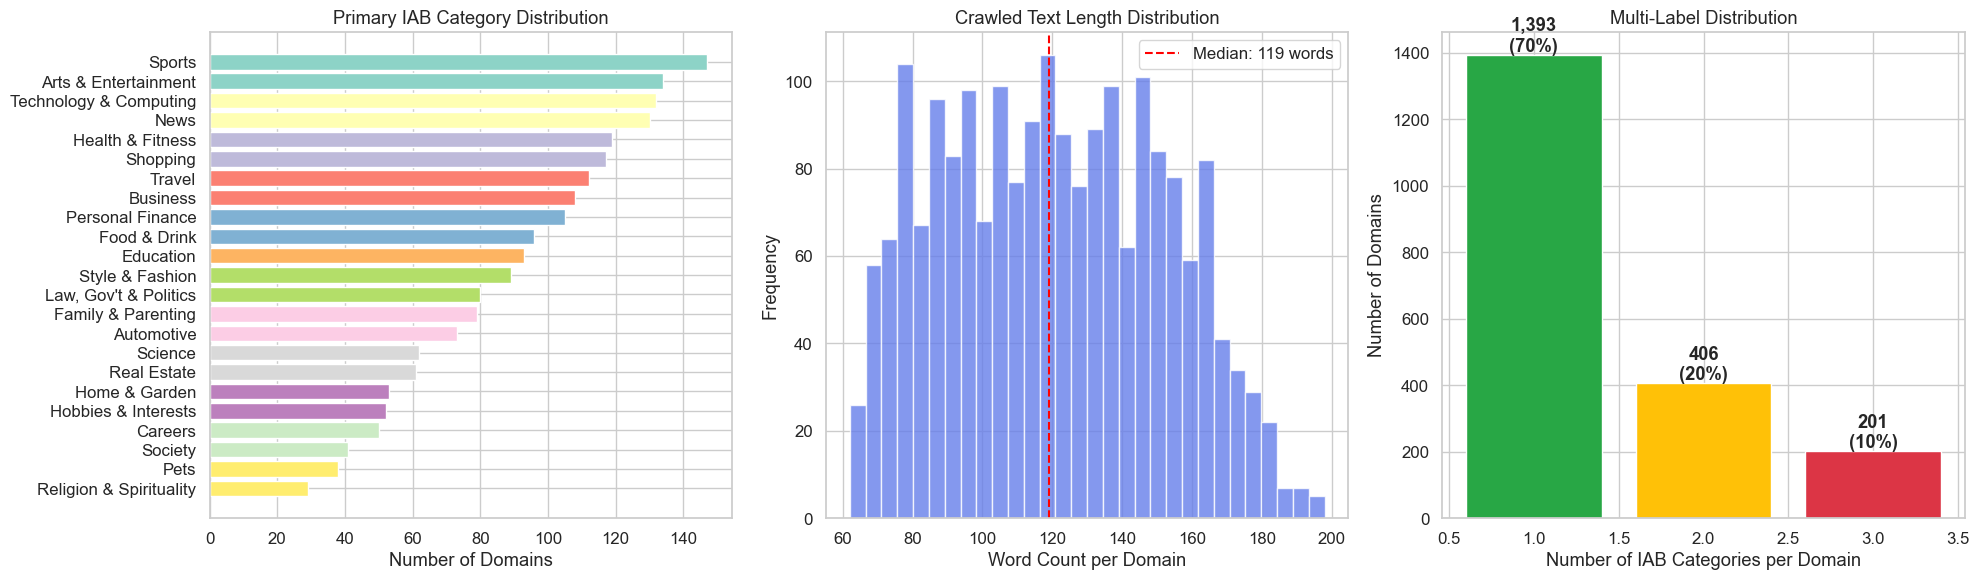


Corpus Summary Statistics:
  Total domains:        2,000
  Unique categories:    23
  Avg words per domain: 120.2
  Min / Max words:      62 / 198
  Multi-label domains:  607 (30.3%)


In [5]:
# ============================================================================
# DOMAIN CORPUS VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Primary category distribution
cat_counts = domain_df["primary_category"].value_counts()
cat_names = [CONFIG["iab_tier1_categories"].get(c, c) for c in cat_counts.index]
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
axes[0].barh(cat_names, cat_counts.values, color=colors)
axes[0].set_xlabel("Number of Domains")
axes[0].set_title("Primary IAB Category Distribution")
axes[0].invert_yaxis()

# 2. Text length distribution (word count)
domain_df["word_count"] = domain_df["text"].str.split().str.len()
axes[1].hist(domain_df["word_count"], bins=30, color="#667eea", edgecolor="white", alpha=0.8)
axes[1].axvline(domain_df["word_count"].median(), color="red", linestyle="--",
                label=f"Median: {domain_df['word_count'].median():.0f} words")
axes[1].set_xlabel("Word Count per Domain")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Crawled Text Length Distribution")
axes[1].legend()

# 3. Multi-label frequency
label_counts = domain_df["iab_categories"].apply(len).value_counts().sort_index()
axes[2].bar(label_counts.index, label_counts.values, color=["#28a745", "#ffc107", "#dc3545"])
axes[2].set_xlabel("Number of IAB Categories per Domain")
axes[2].set_ylabel("Number of Domains")
axes[2].set_title("Multi-Label Distribution")
for i, (x, y) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[2].text(x, y + 10, f"{y:,}\n({y/len(domain_df)*100:.0f}%)",
                 ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/01_domain_corpus_overview.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorpus Summary Statistics:")
print(f"  Total domains:        {len(domain_df):,}")
print(f"  Unique categories:    {domain_df['primary_category'].nunique()}")
print(f"  Avg words per domain: {domain_df['word_count'].mean():.1f}")
print(f"  Min / Max words:      {domain_df['word_count'].min()} / {domain_df['word_count'].max()}")
print(f"  Multi-label domains:  {(domain_df['iab_categories'].apply(len) > 1).sum():,} "
      f"({(domain_df['iab_categories'].apply(len) > 1).mean()*100:.1f}%)")

---
## Step 2: TF-IDF Feature Engineering

### What TF-IDF does and why we chose it

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts raw text into numerical feature vectors by measuring how important each word is to a document relative to the entire corpus.

**The formula:**

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Where:
- **TF(t, d)** = frequency of term `t` in document `d` (we use sublinear: `1 + log(tf)`)
- **IDF(t)** = `log(N / df(t))` where `N` = total documents, `df(t)` = documents containing `t`

### Why TF-IDF over embeddings (Word2Vec, BERT)?

| Criterion | TF-IDF | Word Embeddings | BERT/Transformers |
|-----------|--------|-----------------|-------------------|
| **Latency** | <1ms vectorization | ~5ms | ~50-100ms |
| **Interpretability** | Direct word→weight mapping | Opaque dimensions | Black box |
| **Training data needed** | Works with 1K+ docs | Needs 100K+ | Needs fine-tuning data |
| **Domain vocabulary** | Excellent for specialized terms | May miss rare terms | Good if fine-tuned |
| **Production simplicity** | Serializable, no GPU | Needs embedding lookup | Needs GPU serving |

**Decision:** TF-IDF wins for our domain classification use case because:
1. Domain text is **keyword-rich** — travel sites say "flight," "hotel," "booking" repeatedly
2. We need **sub-5ms inference** on the domain lookup table refresh path
3. We have 200K domains — enough for good IDF statistics but not enough to train embeddings from scratch
4. **Interpretability matters** — when a domain is misclassified, we can inspect which words drove the decision

In [6]:
# ============================================================================
# TF-IDF VECTORIZATION
# Fit on the full domain corpus. In production, this vectorizer is serialized
# (via joblib) and loaded by the batch classification pipeline.
# ============================================================================

tfidf_vectorizer = TfidfVectorizer(
    max_features=CONFIG["tfidf_max_features"],
    ngram_range=CONFIG["tfidf_ngram_range"],
    min_df=CONFIG["tfidf_min_df"],
    max_df=CONFIG["tfidf_max_df"],
    sublinear_tf=CONFIG["tfidf_sublinear_tf"],
    strip_accents="unicode",
    token_pattern=r"(?u)\b\w[\w'-]*\w\b|\b\w\b",  # handles hyphenated terms and single chars
)

# Fit and transform the corpus
X_tfidf = tfidf_vectorizer.fit_transform(domain_df["text"])

feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"  Documents (domains):  {X_tfidf.shape[0]:,}")
print(f"  Features (vocab size): {X_tfidf.shape[1]:,}")
print(f"  Non-zero entries:      {X_tfidf.nnz:,}")
print(f"  Sparsity:              {(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))*100:.2f}%")
print(f"  Memory (sparse):       {X_tfidf.data.nbytes / 1024 / 1024:.2f} MB")
print(f"\nSample feature names (first 20): {list(feature_names[:20])}")
print(f"Sample feature names (last 20):  {list(feature_names[-20:])}")

TF-IDF Matrix Shape: (2000, 20000)
  Documents (domains):  2,000
  Features (vocab size): 20,000
  Non-zero entries:      236,436
  Sparsity:              99.41%
  Memory (sparse):       1.80 MB

Sample feature names (first 20): ['401k', '401k 401k', '401k apr', '401k asset', '401k banking', '401k bond', '401k budget', '401k capital', '401k compound', '401k credit', '401k dividend', '401k etf', '401k family', '401k fico', '401k financial', '401k inflation', '401k insurance', '401k interest', '401k investment', '401k ira']
Sample feature names (last 20):  ['zoning bathroom', 'zoning bedroom', 'zoning buyer', 'zoning closing', 'zoning escrow', 'zoning hoa', 'zoning house', 'zoning kitchen', 'zoning landlord', 'zoning lease', 'zoning listing', 'zoning mls', 'zoning mortgage', 'zoning offer', 'zoning open', 'zoning property', 'zoning realtor', 'zoning rental', 'zoning seller', 'zoning square']


### TF-IDF Worked Example

Let's trace exactly how TF-IDF scores a single domain. This is the kind of debugging you'd do in production when a domain is misclassified — inspect which terms drove the prediction.

Domain: new-shopping-5735.co
Ground Truth Categories: [np.str_('IAB22')]
  → ['Shopping']

Non-zero features: 163 out of 20000

Top 20 TF-IDF Features (these drive the classification):
Rank  Term                       TF-IDF Score
---------------------------------------------
   1  comparison e-commerce            0.1236
   2  review price                     0.1236
   3  black                            0.1159
   4  friday                           0.1159
   5  black friday                     0.1159
   6  deal prime                       0.1144
   7  cart                             0.1104
   8  one                              0.1087
   9  promo                            0.1082
  10  promo code                       0.1082
  11  e-commerce                       0.1080
  12  price                            0.1057
  13  deal                             0.1030
  14  shopping                         0.1016
  15  prime                            0.1004
  16  day                        

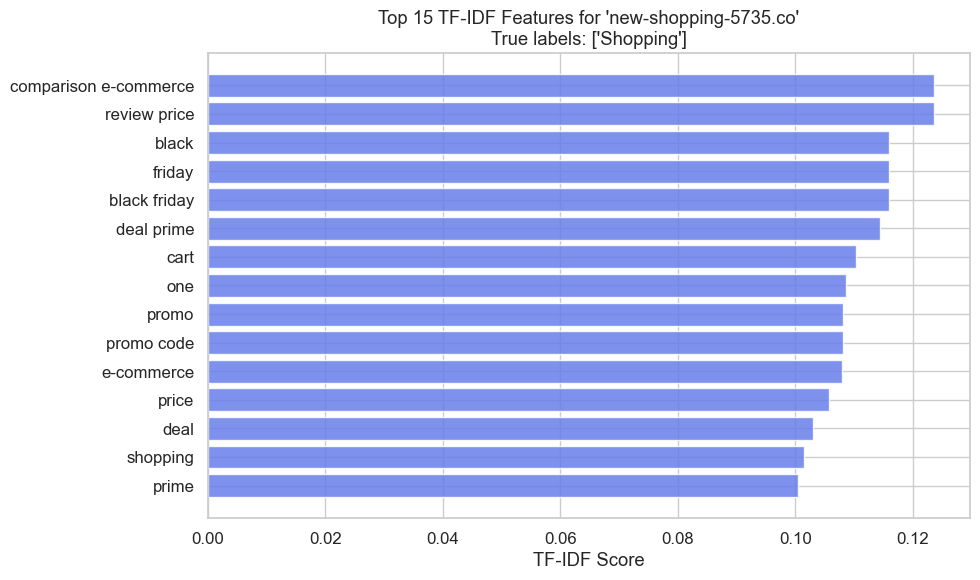

In [7]:
# ============================================================================
# TF-IDF WORKED EXAMPLE — inspect one domain's feature vector
# ============================================================================

example_idx = 0
example_domain = domain_df.iloc[example_idx]
example_vector = X_tfidf[example_idx]

# Extract non-zero features and sort by TF-IDF weight
nonzero_indices = example_vector.nonzero()[1]
tfidf_scores = example_vector.toarray().flatten()
top_features = sorted(
    [(feature_names[i], tfidf_scores[i]) for i in nonzero_indices],
    key=lambda x: -x[1]
)

print(f"Domain: {example_domain['domain']}")
print(f"Ground Truth Categories: {example_domain['iab_categories']}")
print(f"  → {[CONFIG['iab_tier1_categories'][c] for c in example_domain['iab_categories']]}")
print(f"\nNon-zero features: {len(nonzero_indices)} out of {X_tfidf.shape[1]}")
print(f"\nTop 20 TF-IDF Features (these drive the classification):")
print(f"{'Rank':>4}  {'Term':<25}  {'TF-IDF Score':>12}")
print("-" * 45)
for rank, (term, score) in enumerate(top_features[:20], 1):
    print(f"{rank:>4}  {term:<25}  {score:>12.4f}")

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
terms = [t for t, s in top_features[:15]]
scores = [s for t, s in top_features[:15]]
bars = ax.barh(terms[::-1], scores[::-1], color="#667eea", alpha=0.85)
ax.set_xlabel("TF-IDF Score")
ax.set_title(f"Top 15 TF-IDF Features for '{example_domain['domain']}'\n"
             f"True labels: {[CONFIG['iab_tier1_categories'][c] for c in example_domain['iab_categories']]}")
plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/02_tfidf_worked_example.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Step 3: Domain Classification Model — Training & Evaluation

### Model Architecture

We use **OneVsRest Logistic Regression** with probability calibration. This approach:

1. **Trains one binary classifier per IAB category** — each classifier learns "is this domain about Travel? yes/no"
2. **Outputs calibrated probabilities** — not just binary labels, but P(IAB20|domain_text) = 0.82
3. **Handles multi-label natively** — a domain can score high on multiple categories simultaneously

### Why Logistic Regression over tree-based models?

| Factor | Logistic Regression | Random Forest | XGBoost | SGD Classifier |
|--------|-------------------|---------------|---------|----------------|
| **Sparse input handling** | Native — works directly on sparse TF-IDF matrices | Must densify or use specific implementations | Native sparse support via `tree_method='hist'` | Native sparse support |
| **Calibrated probabilities** | Well-calibrated with Platt scaling | Poorly calibrated (bagging effect) | Moderate — better than RF, but post-hoc calibration still helps | Needs calibration |
| **Training time (200K docs)** | ~2 minutes | ~15 minutes | ~5–10 minutes | ~1 minute |
| **Prediction time** | ~0.1ms/doc | ~5ms/doc | ~1ms/doc | ~0.1ms/doc |
| **Interpretability** | Coefficient → word importance | Feature importance only | gain/cover importance + SHAP | Coefficient-based |
| **Overfitting risk** | Low (L2 regularization) | Low (bagging) | Moderate (needs early stopping / depth limits) | Low (regularization) |

We train all four and compare. XGBoost is included because it is the industry standard for tabular/sparse classification tasks and often achieves strong F1 on imbalanced multi-label problems. Logistic Regression remains our production pick for its calibration quality and sub-millisecond latency.

In [8]:
# ============================================================================
# LABEL ENCODING — convert multi-label lists to binary matrix
# ============================================================================

mlb = MultiLabelBinarizer(classes=sorted(CONFIG["iab_tier1_categories"].keys()))
Y_binary = mlb.fit_transform(domain_df["iab_categories"])

print(f"Label matrix shape: {Y_binary.shape}")
print(f"  Domains: {Y_binary.shape[0]:,}")
print(f"  Categories: {Y_binary.shape[1]}")
print(f"  Total positive labels: {Y_binary.sum():,.0f}")
print(f"  Avg labels per domain: {Y_binary.sum(axis=1).mean():.2f}")
print(f"\nLabel frequency per category:")
label_freq = pd.DataFrame({
    "Category": mlb.classes_,
    "Name": [CONFIG["iab_tier1_categories"][c] for c in mlb.classes_],
    "Positive Count": Y_binary.sum(axis=0).astype(int),
    "Prevalence %": (Y_binary.mean(axis=0) * 100).round(2)
}).sort_values("Positive Count", ascending=False)
print(label_freq.to_string(index=False))

Label matrix shape: (2000, 23)
  Domains: 2,000
  Categories: 23
  Total positive labels: 2,808
  Avg labels per domain: 1.40

Label frequency per category:
Category                    Name  Positive Count  Prevalence %
    IAB1    Arts & Entertainment             201         10.05
   IAB17                  Sports             195          9.75
   IAB12                    News             187          9.35
   IAB19  Technology & Computing             172          8.60
    IAB7        Health & Fitness             166          8.30
   IAB22                Shopping             163          8.15
    IAB3                Business             156          7.80
   IAB20                  Travel             156          7.80
   IAB13        Personal Finance             143          7.15
    IAB8            Food & Drink             135          6.75
   IAB18         Style & Fashion             126          6.30
    IAB5               Education             124          6.20
    IAB6      Family & P

### Model Comparison: Train 3 classifiers and compare via cross-validation

We train each model using **5-fold stratified cross-validation** on the primary label. This gives us out-of-fold predictions for every domain — a robust estimate of generalization performance without a separate holdout set (important when categories like IAB23 have few examples).

In [9]:
# ============================================================================
# MODEL COMPARISON — Logistic Regression vs SGD vs Random Forest vs XGBoost
# Using cross-validation on primary_category for stratification.
# We evaluate on the full multi-label target matrix.
# ============================================================================
import time

# Encode primary_category for stratified CV
le = LabelEncoder()
y_primary_encoded = le.fit_transform(domain_df["primary_category"])

cv = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=SEED)

models = {
    "Logistic Regression (L2)": OneVsRestClassifier(
        LogisticRegression(C=CONFIG["classifier_C"], max_iter=CONFIG["classifier_max_iter"],
                           solver="lbfgs", random_state=SEED),
        n_jobs=-1
    ),
    "SGD (Log Loss + L2)": OneVsRestClassifier(
        SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=1000, random_state=SEED),
        n_jobs=-1
    ),
    "Random Forest": OneVsRestClassifier(
        RandomForestClassifier(n_estimators=100, max_depth=20, random_state=SEED, n_jobs=-1),
        n_jobs=-1
    ),
    "XGBoost": OneVsRestClassifier(
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            tree_method="hist",       # native sparse matrix support
            eval_metric="logloss",
            use_label_encoder=False,
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        ),
        n_jobs=-1
    ),
}

results = {}

for name, model in models.items():
    print(f"\nTraining: {name}")
    start_time = time.time()

    # Cross-validated probability predictions
    y_scores = np.zeros_like(Y_binary, dtype=float)

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_tfidf, y_primary_encoded)):
        X_train_fold = X_tfidf[train_idx]
        Y_train_fold = Y_binary[train_idx]
        X_val_fold = X_tfidf[val_idx]

        model.fit(X_train_fold, Y_train_fold)

        if hasattr(model, "predict_proba"):
            y_scores[val_idx] = model.predict_proba(X_val_fold)
        else:
            y_scores[val_idx] = model.decision_function(X_val_fold)

        print(f"  Fold {fold_idx + 1}/{CONFIG['cv_folds']} complete")

    elapsed = time.time() - start_time

    # Threshold probabilities to get binary predictions
    y_pred = (y_scores >= CONFIG["classification_threshold"]).astype(int)

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        Y_binary, y_pred, average="macro", zero_division=0
    )

    # Per-category AUC (only for categories with both positive and negative examples)
    aucs = []
    for i in range(Y_binary.shape[1]):
        if Y_binary[:, i].sum() > 0 and Y_binary[:, i].sum() < len(Y_binary):
            aucs.append(roc_auc_score(Y_binary[:, i], y_scores[:, i]))
    mean_auc = np.mean(aucs) if aucs else 0.0

    results[name] = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_auc": mean_auc,
        "train_time": elapsed,
        "y_scores": y_scores,
        "y_pred": y_pred,
    }

    print(f"  Time: {elapsed:.1f}s | Precision: {precision:.4f} | "
          f"Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {mean_auc:.4f}")

# Summary comparison table
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
comparison_df = pd.DataFrame({
    name: {
        "Macro Precision": f"{r['precision']:.4f}",
        "Macro Recall": f"{r['recall']:.4f}",
        "Macro F1": f"{r['f1']:.4f}",
        "Mean AUC": f"{r['mean_auc']:.4f}",
        "Training Time (s)": f"{r['train_time']:.1f}",
    }
    for name, r in results.items()
}).T
print(comparison_df.to_string())


Training: Logistic Regression (L2)


  Fold 1/5 complete
  Fold 2/5 complete


  Fold 3/5 complete
  Fold 4/5 complete


  Fold 5/5 complete
  Time: 3.0s | Precision: 0.9957 | Recall: 0.8004 | F1: 0.8827 | AUC: 0.9996

Training: SGD (Log Loss + L2)
  Fold 1/5 complete


  Fold 2/5 complete
  Fold 3/5 complete


...

  Fold 1/5 complete


  Fold 2/5 complete


  Fold 3/5 complete


  Fold 4/5 complete


  Fold 5/5 complete
  Time: 14.3s | Precision: 0.8999 | Recall: 0.9163 | F1: 0.9075 | AUC: 0.9984

MODEL COMPARISON SUMMARY
                         Macro Precision Macro Recall Macro F1 Mean AUC Training Time (s)
Logistic Regression (L2)          0.9957       0.8004   0.8827   0.9996               3.0
SGD (Log Loss + L2)               0.9612       0.9063   0.9309   0.9990               0.8
Random Forest                     0.7827       0.9827   0.8679   0.9993               4.0
XGBoost                           0.8999       0.9163   0.9075   0.9984              14.3


### Visualize Model Comparison

We compare models on four axes that matter for production:
1. **F1 Score** — balance of precision and recall per category
2. **AUC** — ranking quality (can we separate positive from negative domains?)
3. **Training time** — how long until we can refresh the domain lookup table?
4. **Per-category performance** — which IAB categories are hardest to classify?

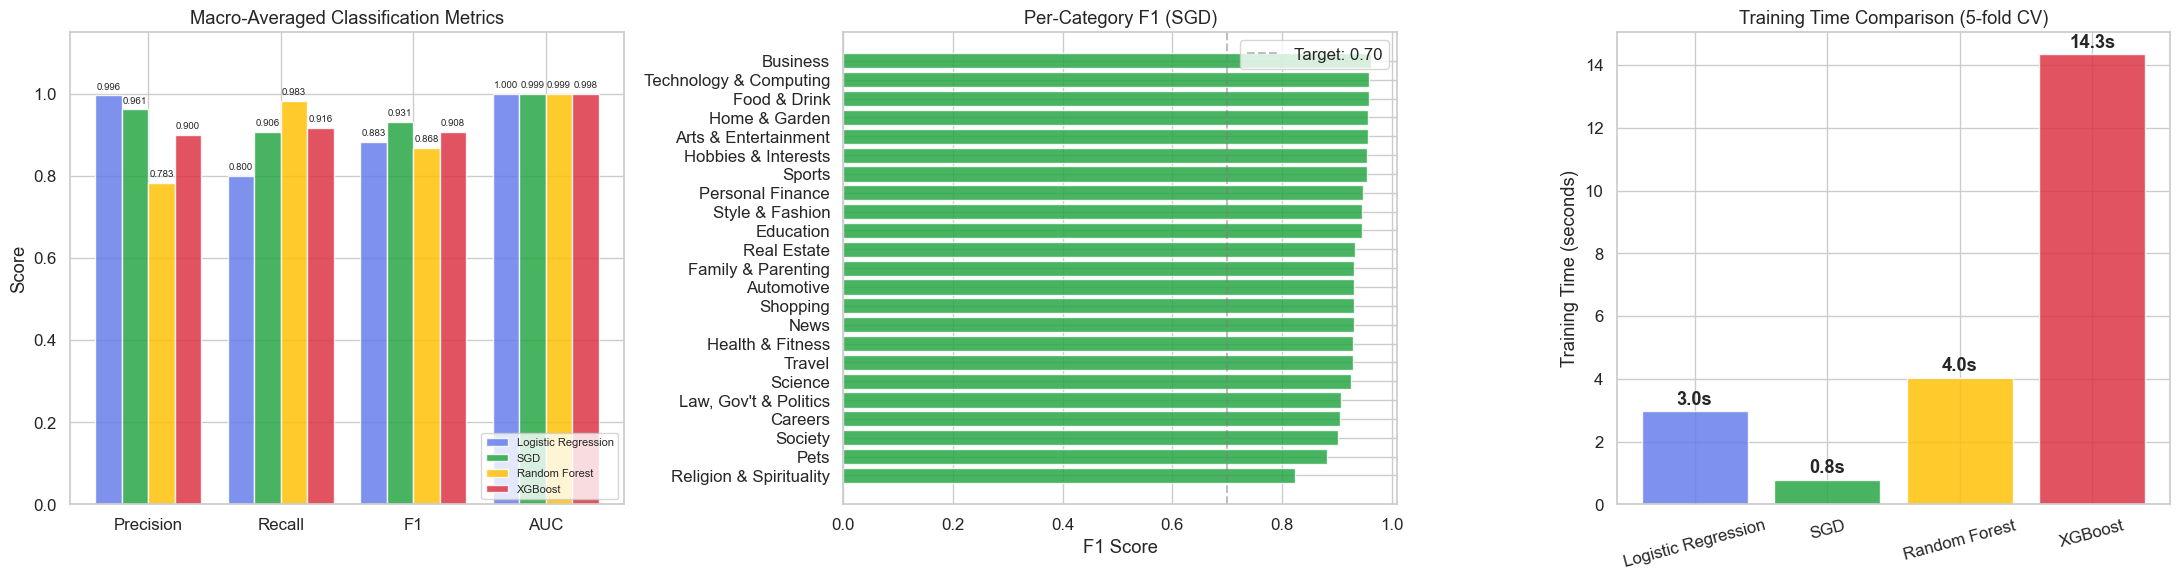


Best model by F1: SGD (Log Loss + L2)
Categories below 0.5 F1 (need attention): []


In [10]:
# ============================================================================
# MODEL COMPARISON VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Macro metrics comparison (bar chart)
metrics = ["precision", "recall", "f1", "mean_auc"]
metric_labels = ["Precision", "Recall", "F1", "AUC"]
x = np.arange(len(metrics))
n_models = len(results)
width = 0.8 / n_models
colors = ["#667eea", "#28a745", "#ffc107", "#dc3545"]

for i, (name, r) in enumerate(results.items()):
    values = [r[m] for m in metrics]
    short_name = name.split(" (")[0] if " (" in name else name
    bars = axes[0].bar(x + i * width, values, width, label=short_name,
                        color=colors[i % len(colors)], alpha=0.85)
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=7)

axes[0].set_xticks(x + width * (n_models - 1) / 2)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylabel("Score")
axes[0].set_title("Macro-Averaged Classification Metrics")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_ylim(0, 1.15)

# 2. Per-category F1 for best model
best_model_name = max(results, key=lambda k: results[k]["f1"])
best_y_pred = results[best_model_name]["y_pred"]
per_cat_f1 = []
for i, cat in enumerate(mlb.classes_):
    _, _, f1_i, _ = precision_recall_fscore_support(
        Y_binary[:, i], best_y_pred[:, i], average="binary", zero_division=0
    )
    per_cat_f1.append((CONFIG["iab_tier1_categories"][cat], f1_i))

per_cat_f1.sort(key=lambda x: x[1])
cat_names_sorted = [c[0] for c in per_cat_f1]
f1_values = [c[1] for c in per_cat_f1]

bar_colors = ["#dc3545" if v < 0.5 else "#ffc107" if v < 0.7 else "#28a745" for v in f1_values]
axes[1].barh(cat_names_sorted, f1_values, color=bar_colors, alpha=0.85)
axes[1].axvline(x=0.7, color="gray", linestyle="--", alpha=0.5, label="Target: 0.70")
axes[1].set_xlabel("F1 Score")
axes[1].set_title(f"Per-Category F1 ({best_model_name.split(' (')[0] if ' (' in best_model_name else best_model_name})")
axes[1].legend()

# 3. Training time comparison
model_names_short = [n.split(" (")[0] if " (" in n else n for n in results.keys()]
train_times = [r["train_time"] for r in results.values()]
bars = axes[2].bar(model_names_short, train_times,
                    color=colors[:len(results)], alpha=0.85)
for bar, t in zip(bars, train_times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{t:.1f}s", ha="center", va="bottom", fontweight="bold")
axes[2].set_ylabel("Training Time (seconds)")
axes[2].set_title("Training Time Comparison (5-fold CV)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/03_model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest model by F1: {best_model_name}")
print(f"Categories below 0.5 F1 (need attention): "
      f"{[c for c, f in per_cat_f1 if f < 0.5]}")

---
## Step 4: Train Production Model & Build Domain Lookup Table

Now we train the **final production model** on the full dataset and generate the **domain → IAB probability lookup table**. This is the artifact that gets deployed to Redis/Aerospike for real-time bidstream enrichment.

### Production artifact structure
```
domain_lookup_table = {
    "cnn.com":     {"IAB12": 0.85, "IAB11": 0.42, "IAB1": 0.31, ...},
    "expedia.com": {"IAB20": 0.92, "IAB22": 0.28, ...},
    ...
}
```
Each entry maps a domain to a dict of IAB category probabilities. At bid time, we look up the domain from the bid request and immediately get the IAB scores — no inference needed.

In [11]:
# ============================================================================
# TRAIN FINAL PRODUCTION MODEL — Calibrated Logistic Regression on full data
# ============================================================================

# Wrap in CalibratedClassifierCV for well-calibrated probabilities
# In production: Platt scaling ensures P(IAB20|text) = 0.8 truly means
# ~80% of domains scored 0.8 actually belong to IAB20.
production_model = OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(
            C=CONFIG["classifier_C"],
            max_iter=CONFIG["classifier_max_iter"],
            solver="lbfgs",
            random_state=SEED,
        ),
        cv=3,
        method="sigmoid",  # Platt scaling
    ),
    n_jobs=-1,
)

start = time.time()
production_model.fit(X_tfidf, Y_binary)
train_time = time.time() - start

# Generate probability predictions for all domains
domain_proba = production_model.predict_proba(X_tfidf)

print(f"Production model trained in {train_time:.2f}s")
print(f"Prediction matrix shape: {domain_proba.shape}")
print(f"  → {domain_proba.shape[0]} domains × {domain_proba.shape[1]} categories")

# ============================================================================
# BUILD DOMAIN LOOKUP TABLE
# For each domain, store only categories with P > threshold (saves memory)
# ============================================================================

domain_lookup = {}
threshold = 0.05  # Store any category with >5% probability

for idx, row in domain_df.iterrows():
    domain = row["domain"]
    probs = domain_proba[idx]
    domain_lookup[domain] = {
        cat: float(prob)
        for cat, prob in zip(mlb.classes_, probs)
        if prob > threshold
    }

# Statistics
avg_cats_per_domain = np.mean([len(v) for v in domain_lookup.values()])
total_entries = sum(len(v) for v in domain_lookup.values())
est_memory_bytes = total_entries * (20 + 8)  # ~20 bytes per key + 8 bytes per float

print(f"\nDomain Lookup Table Built:")
print(f"  Domains:              {len(domain_lookup):,}")
print(f"  Avg categories/domain: {avg_cats_per_domain:.1f}")
print(f"  Total entries:         {total_entries:,}")
print(f"  Est. memory:           {est_memory_bytes / 1024:.1f} KB")
print(f"  (Production with 200K domains: ~{est_memory_bytes / 1024 * 100:.0f} KB ≈ "
      f"{est_memory_bytes / 1024 / 1024 * 100:.1f} MB)")

# Show sample entries
print(f"\nSample lookup entries:")
for domain in list(domain_lookup.keys())[:3]:
    true_cats = domain_df[domain_df["domain"] == domain]["iab_categories"].iloc[0]
    top_predicted = sorted(domain_lookup[domain].items(), key=lambda x: -x[1])[:5]
    print(f"\n  {domain}")
    print(f"    True: {true_cats} → {[CONFIG['iab_tier1_categories'][c] for c in true_cats]}")
    print(f"    Predicted (top 5):")
    for cat, prob in top_predicted:
        name = CONFIG["iab_tier1_categories"][cat]
        match = "✓" if cat in true_cats else " "
        print(f"      {match} {cat} ({name}): {prob:.4f}")

Production model trained in 0.46s
Prediction matrix shape: (2000, 23)
  → 2000 domains × 23 categories

Domain Lookup Table Built:
  Domains:              2,000
  Avg categories/domain: 2.2
  Total entries:         4,456
  Est. memory:           121.8 KB
  (Production with 200K domains: ~12184 KB ≈ 11.9 MB)

Sample lookup entries:

  new-shopping-5735.co
    True: [np.str_('IAB22')] → ['Shopping']
    Predicted (top 5):
      ✓ IAB22 (Shopping): 0.9997
        IAB11 (Law, Gov't & Politics): 0.1034

  new-fashion-5802.co
    True: [np.str_('IAB18'), np.str_('IAB17')] → ['Style & Fashion', 'Sports']
    Predicted (top 5):
      ✓ IAB18 (Style & Fashion): 0.9829
      ✓ IAB17 (Sports): 0.9747
        IAB12 (News): 0.1011

  elite-shopping-5487.org
    True: [np.str_('IAB22')] → ['Shopping']
    Predicted (top 5):
      ✓ IAB22 (Shopping): 0.9985
        IAB15 (Science): 0.0636


### Detailed Classification Report & Confusion Analysis

This is the production quality gate. Before deploying a new domain lookup table, we verify:
1. **No category drops below acceptable F1** (threshold: 0.60)
2. **Confusion patterns are expected** (News confused with Politics is acceptable; Travel confused with Pets is a bug)
3. **Calibration** — predicted probabilities match actual frequencies

In [12]:
# ============================================================================
# DETAILED CLASSIFICATION REPORT (using cross-validation predictions)
# ============================================================================

best_y_scores = results[best_model_name]["y_scores"]
best_y_pred = results[best_model_name]["y_pred"]

print(f"Classification Report — {best_model_name}")
print(f"Threshold: {CONFIG['classification_threshold']}")
print("=" * 85)

# Per-category detailed metrics
cat_metrics = []
for i, cat in enumerate(mlb.classes_):
    n_pos = Y_binary[:, i].sum()
    n_pred_pos = best_y_pred[:, i].sum()
    p, r, f, _ = precision_recall_fscore_support(
        Y_binary[:, i], best_y_pred[:, i], average="binary", zero_division=0
    )
    cat_metrics.append({
        "Category": cat,
        "Name": CONFIG["iab_tier1_categories"][cat],
        "Support": int(n_pos),
        "Predicted": int(n_pred_pos),
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1": round(f, 4),
    })

metrics_df = pd.DataFrame(cat_metrics).sort_values("F1", ascending=False)
print(metrics_df.to_string(index=False))

# Summary statistics
print(f"\n{'─' * 85}")
macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(
    Y_binary, best_y_pred, average="macro", zero_division=0
)
micro_p, micro_r, micro_f, _ = precision_recall_fscore_support(
    Y_binary, best_y_pred, average="micro", zero_division=0
)
print(f"  Macro avg:  Precision={macro_p:.4f}  Recall={macro_r:.4f}  F1={macro_f:.4f}")
print(f"  Micro avg:  Precision={micro_p:.4f}  Recall={micro_r:.4f}  F1={micro_f:.4f}")

below_threshold = metrics_df[metrics_df["F1"] < 0.60]
if len(below_threshold) > 0:
    print(f"\n⚠ ALERT: {len(below_threshold)} categories below 0.60 F1 threshold:")
    for _, row in below_threshold.iterrows():
        print(f"    {row['Category']} ({row['Name']}): F1={row['F1']}, Support={row['Support']}")
else:
    print(f"\n✓ All categories meet the 0.60 F1 minimum threshold.")

Classification Report — SGD (Log Loss + L2)
Threshold: 0.3
Category                    Name  Support  Predicted  Precision  Recall     F1
    IAB3                Business      156        160     0.9500  0.9744 0.9620
   IAB19  Technology & Computing      172        174     0.9540  0.9651 0.9595
    IAB8            Food & Drink      135        130     0.9769  0.9407 0.9585
   IAB10           Home & Garden       73         67     1.0000  0.9178 0.9571
    IAB1    Arts & Entertainment      201        209     0.9378  0.9751 0.9561
    IAB9     Hobbies & Interests       80         77     0.9740  0.9375 0.9554
   IAB17                  Sports      195        184     0.9837  0.9282 0.9551
   IAB13        Personal Finance      143        148     0.9324  0.9650 0.9485
   IAB18         Style & Fashion      126        117     0.9829  0.9127 0.9465
    IAB5               Education      124        117     0.9744  0.9194 0.9461
   IAB21             Real Estate       95         87     0.9770  0.8947 

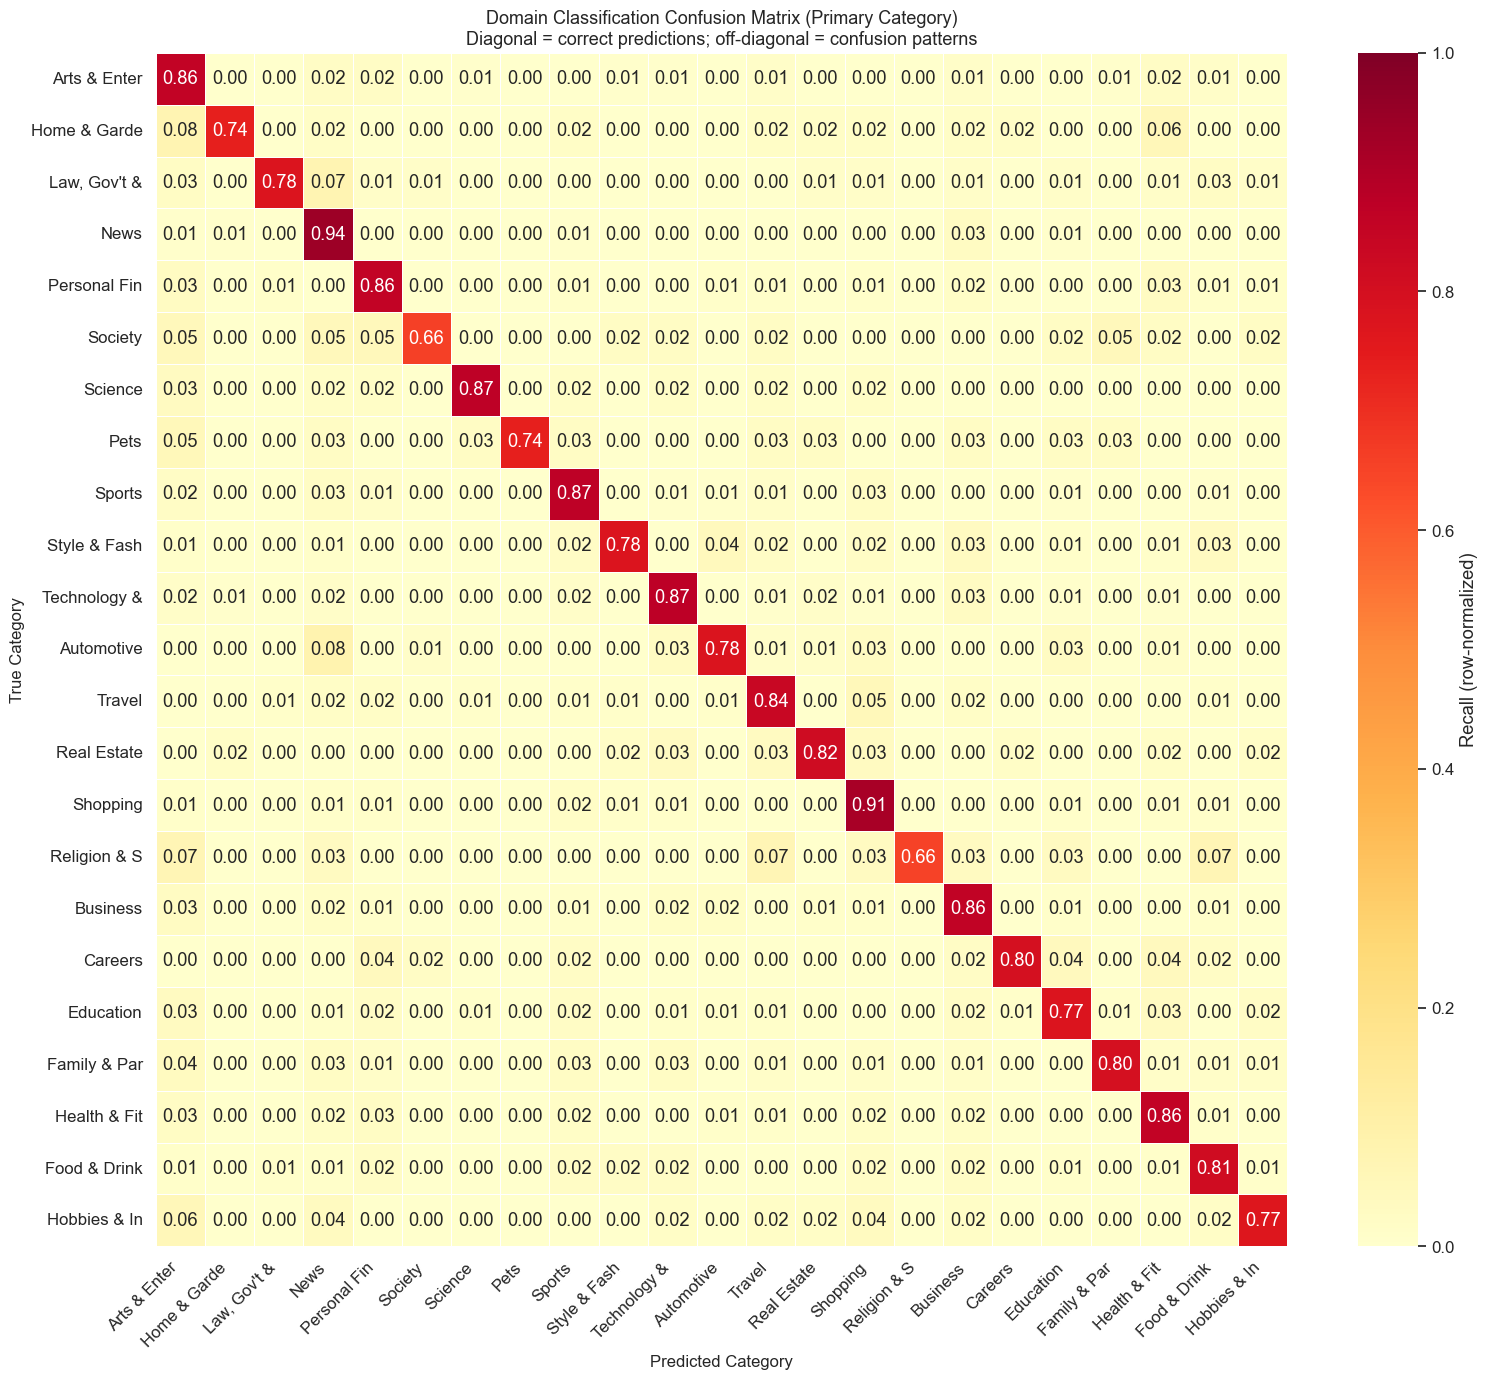

Top 10 Confusion Pairs (off-diagonal):
True Category             Predicted As                  Rate
------------------------------------------------------------
  Automotive                News                         8.2%
  Home & Garden             Arts & Entertainment         7.5%
  Law, Gov't & Politics     News                         7.5%
  Religion & Spirituality   Arts & Entertainment         6.9%
  Religion & Spirituality   Travel                       6.9%
  Religion & Spirituality   Food & Drink                 6.9%
  Hobbies & Interests       Arts & Entertainment         5.8%
  Home & Garden             Health & Fitness             5.7%
  Travel                    Shopping                     5.4%
  Pets                      Arts & Entertainment         5.3%


In [13]:
# ============================================================================
# CONFUSION MATRIX HEATMAP — which categories get confused with each other?
# Using primary_category (single-label) for a clean confusion matrix.
# ============================================================================

# For primary category: take the argmax of predicted scores as the predicted primary
primary_pred_idx = best_y_scores.argmax(axis=1)
primary_true_idx = np.array([list(mlb.classes_).index(c) for c in domain_df["primary_category"]])

cat_short_names = [CONFIG["iab_tier1_categories"][c][:12] for c in mlb.classes_]

cm = confusion_matrix(primary_true_idx, primary_pred_idx,
                      labels=list(range(len(mlb.classes_))))

# Normalize by row (true label) to show recall per category
cm_normalized = cm.astype(float)
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
cm_normalized = cm_normalized / row_sums

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=cat_short_names, yticklabels=cat_short_names,
            ax=ax, vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={"label": "Recall (row-normalized)"})
ax.set_xlabel("Predicted Category", fontsize=12)
ax.set_ylabel("True Category", fontsize=12)
ax.set_title("Domain Classification Confusion Matrix (Primary Category)\n"
             "Diagonal = correct predictions; off-diagonal = confusion patterns", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/plots/04_confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Identify top confusion pairs
print("Top 10 Confusion Pairs (off-diagonal):")
print(f"{'True Category':<25} {'Predicted As':<25} {'Rate':>8}")
print("-" * 60)
confusion_pairs = []
for i in range(len(mlb.classes_)):
    for j in range(len(mlb.classes_)):
        if i != j and cm_normalized[i, j] > 0.02:
            confusion_pairs.append((
                CONFIG["iab_tier1_categories"][mlb.classes_[i]],
                CONFIG["iab_tier1_categories"][mlb.classes_[j]],
                cm_normalized[i, j]
            ))
confusion_pairs.sort(key=lambda x: -x[2])
for true_cat, pred_cat, rate in confusion_pairs[:10]:
    print(f"  {true_cat:<25} {pred_cat:<25} {rate:>7.1%}")

---
## Save Pipeline Artifacts

Serialize all artifacts that Part 2 needs. We save:
- **`domain_df.parquet`** — the domain corpus (human-inspectable format)
- **`pipeline_artifacts.pkl`** — everything else in a single bundle

In production, the domain lookup table would be written to Redis/Aerospike instead of a pickle file.

In [14]:
# ============================================================================
# SAVE ARTIFACTS FOR PART 2
# ============================================================================
import pickle, os

ARTIFACTS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Save domain DataFrame as parquet (human-inspectable)
domain_df.to_parquet(os.path.join(ARTIFACTS_DIR, 'domain_df.parquet'), index=False)

# Bundle evaluation artifacts
artifacts = {
    'CONFIG': CONFIG,
    'domain_lookup': domain_lookup,
    'X_tfidf': X_tfidf,
    'Y_binary': Y_binary,
    'mlb': mlb,
    'feature_names': feature_names,
    'results': results,
    'best_model_name': best_model_name,
    'best_y_scores': best_y_scores,
    'best_y_pred': best_y_pred,
    'train_time': train_time,
    'est_memory_bytes': est_memory_bytes,
}

pkl_path = os.path.join(ARTIFACTS_DIR, 'pipeline_artifacts.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump(artifacts, f, protocol=pickle.HIGHEST_PROTOCOL)

# Save classification model + vectorizer separately
# (needed by Part 2's real-time classifier fallback)
model_artifacts = {
    'tfidf_vectorizer': tfidf_vectorizer,
    'production_model': production_model,
}
model_path = os.path.join(ARTIFACTS_DIR, 'classification_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_artifacts, f, protocol=pickle.HIGHEST_PROTOCOL)

# Verify
pkl_size = os.path.getsize(pkl_path) / 1024 / 1024
pq_size = os.path.getsize(os.path.join(ARTIFACTS_DIR, 'domain_df.parquet')) / 1024 / 1024
model_size = os.path.getsize(model_path) / 1024 / 1024

print(f'Artifacts saved to: {ARTIFACTS_DIR}/')
print(f'  domain_df.parquet:        {pq_size:.2f} MB')
print(f'  pipeline_artifacts.pkl:   {pkl_size:.2f} MB')
print(f'  classification_model.pkl: {model_size:.2f} MB')
print(f'  Total:                    {pkl_size + pq_size + model_size:.2f} MB')
print()
print('Artifact contents (pipeline_artifacts.pkl):')
for key, val in artifacts.items():
    if hasattr(val, 'shape'):
        print(f'  {key:<25} shape={val.shape}')
    elif isinstance(val, dict) and len(val) > 10:
        print(f'  {key:<25} dict with {len(val):,} entries')
    elif isinstance(val, str):
        print(f'  {key:<25} {repr(val)}')
    else:
        print(f'  {key:<25} {type(val).__name__}')
print()
print('classification_model.pkl: tfidf_vectorizer + production_model')
print()
print('Part 2 notebook can now be executed.')


Artifacts saved to: /Users/nipun.batra/Downloads/ML/NLP IAB Real-Time Audience Classification Pipeline/notebooks/../artifacts/
  domain_df.parquet:        0.71 MB
  pipeline_artifacts.pkl:   6.31 MB
  classification_model.pkl: 11.43 MB
  Total:                    18.45 MB

Artifact contents (pipeline_artifacts.pkl):
  CONFIG                    dict with 20 entries
  domain_lookup             dict with 2,000 entries
  X_tfidf                   shape=(2000, 20000)
  Y_binary                  shape=(2000, 23)
  mlb                       MultiLabelBinarizer
  feature_names             shape=(20000,)
  results                   dict
  best_model_name           'SGD (Log Loss + L2)'
  best_y_scores             shape=(2000, 23)
  best_y_pred               shape=(2000, 23)
  train_time                float
  est_memory_bytes          int

classification_model.pkl: tfidf_vectorizer + production_model

Part 2 notebook can now be executed.
